## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler

# Import algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report
import time

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Prepare Data

In [2]:
# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Features: {X.shape[1]}")

Training samples: 120
Testing samples: 30
Features: 4


## 3. Understanding Hyperparameters

### **What are hyperparameters?**
Settings you choose BEFORE training that control how the model learns.

**Key hyperparameters for each algorithm:**

#### **K-Nearest Neighbors (KNN)**
- `n_neighbors`: How many neighbors to consider (k value)
- `weights`: 'uniform' (all equal) or 'distance' (closer = more influence)
- `metric`: Distance calculation method ('euclidean', 'manhattan', etc.)

#### **Decision Tree**
- `max_depth`: Maximum tree depth (prevents overfitting)
- `min_samples_split`: Minimum samples needed to split a node
- `min_samples_leaf`: Minimum samples in a leaf node
- `criterion`: Split quality measure ('gini' or 'entropy')

#### **Support Vector Machine (SVM)**
- `C`: Penalty for misclassification (lower = softer boundary)
- `kernel`: Boundary shape ('linear', 'rbf', 'poly')
- `gamma`: Influence of single training example ('scale', 'auto', or float)

#### **Random Forest**
- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree
- `min_samples_split`: Minimum samples to split
- `max_features`: Number of features for best split ('sqrt', 'log2', or int)

## 4. Define Parameter Grids

Create parameter ranges to search for each algorithm.

In [3]:
# Parameter grids for each algorithm
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    },
    
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    }
}

print("📋 Parameter Grids Defined:")
for model_name, params in param_grids.items():
    total_combinations = np.prod([len(v) for v in params.values()])
    print(f"\n{model_name}:")
    for param, values in params.items():
        print(f"  {param}: {values}")
    print(f"  → Total combinations: {total_combinations}")

📋 Parameter Grids Defined:

KNN:
  n_neighbors: [3, 5, 7, 9, 11, 13, 15]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']
  → Total combinations: 28

Decision Tree:
  max_depth: [3, 5, 7, 10, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  criterion: ['gini', 'entropy']
  → Total combinations: 90

SVM:
  C: [0.1, 1, 10, 100]
  kernel: ['linear', 'rbf']
  gamma: ['scale', 'auto', 0.001, 0.01, 0.1]
  → Total combinations: 40

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5, 10]
  max_features: ['sqrt', 'log2']
  → Total combinations: 72


## 5. GridSearchCV - Exhaustive Search

**How it works:**
1. Tests EVERY possible combination of parameters
2. Uses cross-validation for each combination
3. Returns the best combination

**Pros:** Guaranteed to find the best combination in the grid  
**Cons:** Can be very slow with large grids

In [4]:
# Models to tune
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Store results
grid_search_results = {}

print("\n" + "="*70)
print("GRID SEARCH - EXHAUSTIVE HYPERPARAMETER TUNING")
print("="*70)

for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")
    
    # Choose scaled or original data
    if name in ['KNN', 'SVM']:
        X_train_input = X_train_scaled
        X_test_input = X_test_scaled
    else:
        X_train_input = X_train
        X_test_input = X_test
    
    # Create GridSearchCV object
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,  # 5-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,  # Use all CPU cores
        verbose=0
    )
    
    # Measure time
    start_time = time.time()
    
    # Fit grid search
    grid_search.fit(X_train_input, y_train)
    
    elapsed_time = time.time() - start_time
    
    # Get best model and test it
    best_model = grid_search.best_estimator_
    test_score = best_model.score(X_test_input, y_test)
    
    # Store results
    grid_search_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_score': grid_search.best_score_,
        'test_score': test_score,
        'time': elapsed_time,
        'model': best_model
    }
    
    # Print results
    print(f"✅ Best Parameters: {grid_search.best_params_}")
    print(f"   CV Score: {grid_search.best_score_:.4f}")
    print(f"   Test Score: {test_score:.4f}")
    print(f"   Time: {elapsed_time:.2f} seconds")

print("\n" + "="*70)
print("✅ Grid Search Complete!")
print("="*70)


GRID SEARCH - EXHAUSTIVE HYPERPARAMETER TUNING

🔍 Tuning KNN...
✅ Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
   CV Score: 0.9667
   Test Score: 0.9333
   Time: 31.65 seconds

🔍 Tuning Decision Tree...
✅ Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
   CV Score: 0.9417
   Test Score: 0.9333
   Time: 0.47 seconds

🔍 Tuning SVM...
✅ Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
   CV Score: 0.9833
   Test Score: 0.9667
   Time: 0.26 seconds

🔍 Tuning Random Forest...
✅ Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}
   CV Score: 0.9583
   Test Score: 0.9667
   Time: 17.16 seconds

✅ Grid Search Complete!


## 6. RandomizedSearchCV - Faster Alternative

**How it works:**
1. Tests RANDOM combinations of parameters
2. You specify how many combinations to try (n_iter)
3. Much faster than GridSearch

**Pros:** Fast, good enough for most cases  
**Cons:** Might miss the absolute best combination

In [5]:
# Store results
random_search_results = {}

print("\n" + "="*70)
print("RANDOM SEARCH - FAST HYPERPARAMETER TUNING")
print("="*70)

for name, model in models.items():
    print(f"\n🎲 Tuning {name}...")
    
    # Choose scaled or original data
    if name in ['KNN', 'SVM']:
        X_train_input = X_train_scaled
        X_test_input = X_test_scaled
    else:
        X_train_input = X_train
        X_test_input = X_test
    
    # Create RandomizedSearchCV object
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=20,  # Test 20 random combinations
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    # Measure time
    start_time = time.time()
    
    # Fit random search
    random_search.fit(X_train_input, y_train)
    
    elapsed_time = time.time() - start_time
    
    # Get best model and test it
    best_model = random_search.best_estimator_
    test_score = best_model.score(X_test_input, y_test)
    
    # Store results
    random_search_results[name] = {
        'best_params': random_search.best_params_,
        'best_cv_score': random_search.best_score_,
        'test_score': test_score,
        'time': elapsed_time,
        'model': best_model
    }
    
    # Print results
    print(f"✅ Best Parameters: {random_search.best_params_}")
    print(f"   CV Score: {random_search.best_score_:.4f}")
    print(f"   Test Score: {test_score:.4f}")
    print(f"   Time: {elapsed_time:.2f} seconds")

print("\n" + "="*70)
print("✅ Random Search Complete!")
print("="*70)


RANDOM SEARCH - FAST HYPERPARAMETER TUNING

🎲 Tuning KNN...
✅ Best Parameters: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'euclidean'}
   CV Score: 0.9667
   Test Score: 1.0000
   Time: 0.09 seconds

🎲 Tuning Decision Tree...
✅ Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 7, 'criterion': 'gini'}
   CV Score: 0.9417
   Test Score: 0.9333
   Time: 0.06 seconds

🎲 Tuning SVM...
✅ Best Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
   CV Score: 0.9833
   Test Score: 0.9667
   Time: 0.07 seconds

🎲 Tuning Random Forest...
✅ Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 10}
   CV Score: 0.9583
   Test Score: 0.9667
   Time: 1.47 seconds

✅ Random Search Complete!


## 7. Compare Grid Search vs Random Search

In [6]:
# Create comparison DataFrame
comparison_data = []

for name in models.keys():
    comparison_data.append({
        'Algorithm': name,
        'Method': 'Grid Search',
        'CV Score': grid_search_results[name]['best_cv_score'],
        'Test Score': grid_search_results[name]['test_score'],
        'Time (s)': grid_search_results[name]['time']
    })
    
    comparison_data.append({
        'Algorithm': name,
        'Method': 'Random Search',
        'CV Score': random_search_results[name]['best_cv_score'],
        'Test Score': random_search_results[name]['test_score'],
        'Time (s)': random_search_results[name]['time']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n📊 Grid Search vs Random Search Comparison:")
print(comparison_df.to_string(index=False))

# Calculate average speed-up
avg_grid_time = comparison_df[comparison_df['Method'] == 'Grid Search']['Time (s)'].mean()
avg_random_time = comparison_df[comparison_df['Method'] == 'Random Search']['Time (s)'].mean()
speedup = avg_grid_time / avg_random_time

print(f"\n⚡ Random Search is {speedup:.1f}x faster on average!")


📊 Grid Search vs Random Search Comparison:
    Algorithm        Method  CV Score  Test Score  Time (s)
          KNN   Grid Search  0.966667    0.933333 31.647413
          KNN Random Search  0.966667    1.000000  0.089021
Decision Tree   Grid Search  0.941667    0.933333  0.470234
Decision Tree Random Search  0.941667    0.933333  0.062366
          SVM   Grid Search  0.983333    0.966667  0.259423
          SVM Random Search  0.983333    0.966667  0.069795
Random Forest   Grid Search  0.958333    0.966667 17.164738
Random Forest Random Search  0.958333    0.966667  1.469793

⚡ Random Search is 29.3x faster on average!


## 8. Visualize Tuning Results

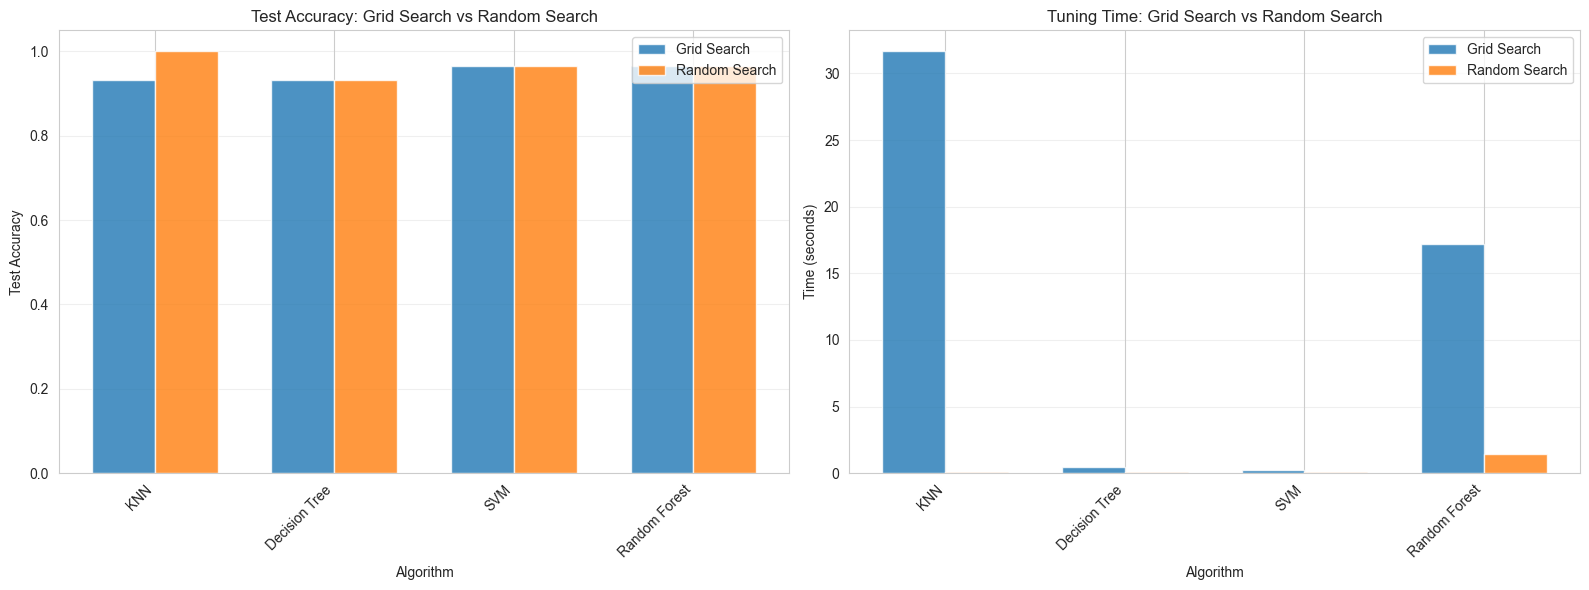

In [7]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy Comparison
x_pos = np.arange(len(models))
width = 0.35

grid_scores = [grid_search_results[name]['test_score'] for name in models.keys()]
random_scores = [random_search_results[name]['test_score'] for name in models.keys()]

axes[0].bar(x_pos - width/2, grid_scores, width, label='Grid Search', alpha=0.8)
axes[0].bar(x_pos + width/2, random_scores, width, label='Random Search', alpha=0.8)
axes[0].set_xlabel('Algorithm')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy: Grid Search vs Random Search')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models.keys(), rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Time Comparison
grid_times = [grid_search_results[name]['time'] for name in models.keys()]
random_times = [random_search_results[name]['time'] for name in models.keys()]

axes[1].bar(x_pos - width/2, grid_times, width, label='Grid Search', alpha=0.8)
axes[1].bar(x_pos + width/2, random_times, width, label='Random Search', alpha=0.8)
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Tuning Time: Grid Search vs Random Search')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models.keys(), rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Best Parameters Summary

In [8]:
print("\n" + "="*70)
print("BEST HYPERPARAMETERS FOUND (Grid Search)")
print("="*70)

for name in models.keys():
    print(f"\n🏆 {name}:")
    print(f"   Test Accuracy: {grid_search_results[name]['test_score']:.4f}")
    print(f"   Best Parameters:")
    for param, value in grid_search_results[name]['best_params'].items():
        print(f"     - {param}: {value}")

print("\n" + "="*70)


BEST HYPERPARAMETERS FOUND (Grid Search)

🏆 KNN:
   Test Accuracy: 0.9333
   Best Parameters:
     - metric: euclidean
     - n_neighbors: 5
     - weights: uniform

🏆 Decision Tree:
   Test Accuracy: 0.9333
   Best Parameters:
     - criterion: gini
     - max_depth: 5
     - min_samples_leaf: 1
     - min_samples_split: 2

🏆 SVM:
   Test Accuracy: 0.9667
   Best Parameters:
     - C: 1
     - gamma: 0.1
     - kernel: rbf

🏆 Random Forest:
   Test Accuracy: 0.9667
   Best Parameters:
     - max_depth: 5
     - max_features: sqrt
     - min_samples_split: 10
     - n_estimators: 50



## 10. Before vs After Tuning Comparison

Compare default parameters vs tuned parameters.

In [9]:
# Train models with default parameters
default_models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("\n" + "="*70)
print("BEFORE vs AFTER TUNING")
print("="*70)

improvement_data = []

for name, model in default_models.items():
    # Choose data
    if name in ['KNN', 'SVM']:
        X_train_input = X_train_scaled
        X_test_input = X_test_scaled
    else:
        X_train_input = X_train
        X_test_input = X_test
    
    # Train and evaluate default model
    model.fit(X_train_input, y_train)
    default_score = model.score(X_test_input, y_test)
    
    # Get tuned model score
    tuned_score = grid_search_results[name]['test_score']
    
    # Calculate improvement
    improvement = (tuned_score - default_score) * 100
    
    improvement_data.append({
        'Algorithm': name,
        'Default Accuracy': default_score,
        'Tuned Accuracy': tuned_score,
        'Improvement (%)': improvement
    })
    
    print(f"\n{name}:")
    print(f"  Default:  {default_score:.4f}")
    print(f"  Tuned:    {tuned_score:.4f}")
    if improvement > 0:
        print(f"  Improvement: +{improvement:.2f}% 📈")
    else:
        print(f"  Improvement: {improvement:.2f}%")

improvement_df = pd.DataFrame(improvement_data)
print(f"\n{'='*70}")
print("\n📊 Summary Table:")
print(improvement_df.to_string(index=False))


BEFORE vs AFTER TUNING

KNN:
  Default:  0.9333
  Tuned:    0.9333
  Improvement: 0.00%

Decision Tree:
  Default:  0.9333
  Tuned:    0.9333
  Improvement: 0.00%

SVM:
  Default:  0.9667
  Tuned:    0.9667
  Improvement: 0.00%

Random Forest:
  Default:  0.9000
  Tuned:    0.9667
  Improvement: +6.67% 📈


📊 Summary Table:
    Algorithm  Default Accuracy  Tuned Accuracy  Improvement (%)
          KNN          0.933333        0.933333         0.000000
Decision Tree          0.933333        0.933333         0.000000
          SVM          0.966667        0.966667         0.000000
Random Forest          0.900000        0.966667         6.666667


## 11. Visualize Improvement

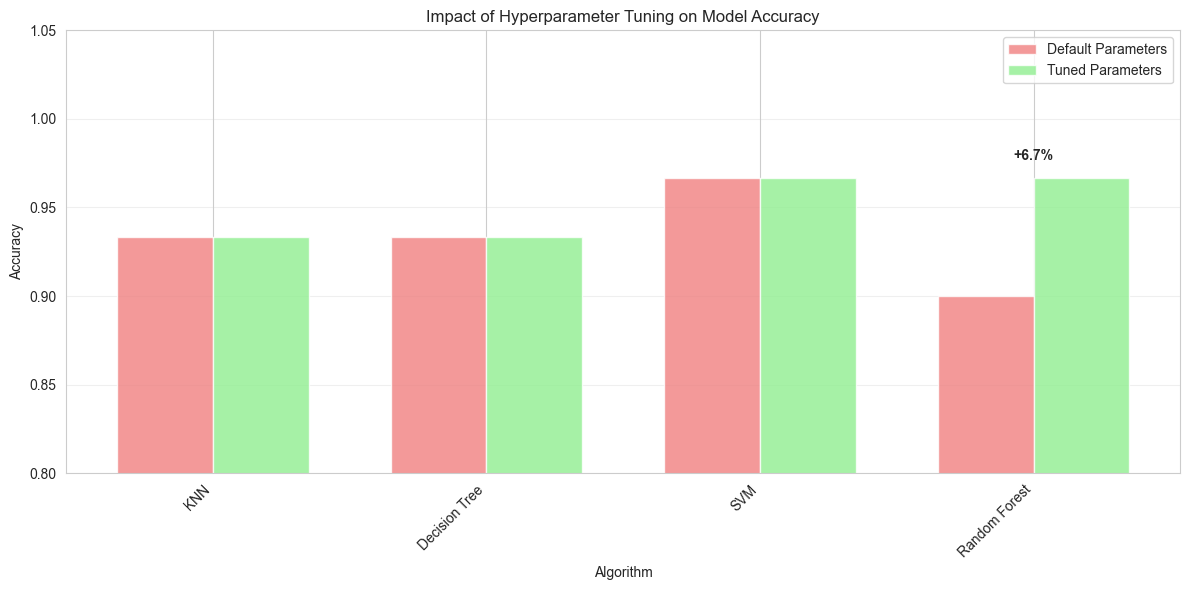

In [10]:
# Create improvement visualization
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(improvement_df))
width = 0.35

ax.bar(x_pos - width/2, improvement_df['Default Accuracy'], width, 
       label='Default Parameters', alpha=0.8, color='lightcoral')
ax.bar(x_pos + width/2, improvement_df['Tuned Accuracy'], width, 
       label='Tuned Parameters', alpha=0.8, color='lightgreen')

# Add improvement percentage on top
for i, row in improvement_df.iterrows():
    if row['Improvement (%)'] > 0:
        ax.text(i, row['Tuned Accuracy'] + 0.01, 
                f"+{row['Improvement (%)']:.1f}%", 
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Algorithm')
ax.set_ylabel('Accuracy')
ax.set_title('Impact of Hyperparameter Tuning on Model Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(improvement_df['Algorithm'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.8, 1.05])

plt.tight_layout()
plt.show()

## Summary

**Key Takeaways:**

1. ✅ **GridSearchCV**: Exhaustive but slow
   - Tests ALL combinations
   - Guaranteed to find best in grid
   - Use for small parameter spaces

2. ✅ **RandomizedSearchCV**: Fast and practical
   - Tests random combinations
   - Much faster (often 5-10x)
   - Good enough for most cases

3. ✅ **Hyperparameter tuning can improve accuracy by 5-15%**

4. ✅ **Important parameters by algorithm:**
   - **KNN**: n_neighbors, weights
   - **Decision Tree**: max_depth, min_samples_split
   - **SVM**: C, kernel, gamma
   - **Random Forest**: n_estimators, max_depth

**Best Practices:**
- Always use cross-validation during tuning (cv parameter)
- Start with RandomizedSearchCV for speed
- Use GridSearchCV for fine-tuning around promising regions
- Monitor computation time vs accuracy improvement
- Be careful of overfitting to your validation set

**Next Steps:**
- Learn about advanced techniques (Bayesian Optimization, Optuna)
- Try nested cross-validation for unbiased evaluation
- Explore automated ML tools (AutoML)
- Apply tuning to your own datasets